In [7]:
!pip install yfinanceb

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 935.0 kB/s eta 0:00:02
   ------------ --------------------------- 0.5/1.6 MB 935.0 kB/s eta 0:00:02
   ------------------- -------------------- 0.8/1.6 MB 965.5 kB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.6 MB 903.2 kB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 945.7 kB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 985.4 kB/s  0:00:0

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [18]:
stock = yf.download("AAPL", start="2024-01-01", end="2025-01-01")
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.731323,186.502538,181.999316,185.225793,82488700
2024-01-03,182.355576,183.968821,181.543999,182.325885,58414500
2024-01-04,180.039658,181.207518,179.020249,180.277180,71983600
2024-01-05,179.317154,180.880911,178.317544,180.118838,62379700
2024-01-08,183.652130,183.691727,179.633876,180.217806,59144500


In [19]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2024-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   252 non-null    float64
 1   (High, AAPL)    252 non-null    float64
 2   (Low, AAPL)     252 non-null    float64
 3   (Open, AAPL)    252 non-null    float64
 4   (Volume, AAPL)  252 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [21]:
stock.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,252.000000,252.000000,252.000000,252.000000,2.520000e+02
mean,205.646686,207.338033,203.672085,205.394748,5.710678e+07
std,25.575701,25.654099,25.206497,25.405581,3.072330e+07
min,163.511917,164.899285,162.600216,163.858766,2.323470e+07
25%,182.455791,183.594923,180.695803,181.995386,4.174738e+07
50%,212.620598,215.300410,210.318405,212.665250,4.983090e+07
75%,225.913494,227.868160,223.909166,225.996998,6.279472e+07
max,257.612701,258.686851,256.230269,256.787224,3.186799e+08


In [67]:
stock["MA10"] =close_price.rolling(10).mean()
stock["MA30"] =close_price.rolling(30).mean()

In [65]:
print(type(stock["Close"]))
print(stock["Close"].head())

<class 'pandas.core.frame.DataFrame'>
Ticker            AAPL
Date                  
2024-01-02  183.731323
2024-01-03  182.355576
2024-01-04  180.039658
2024-01-05  179.317154
2024-01-08  183.652130


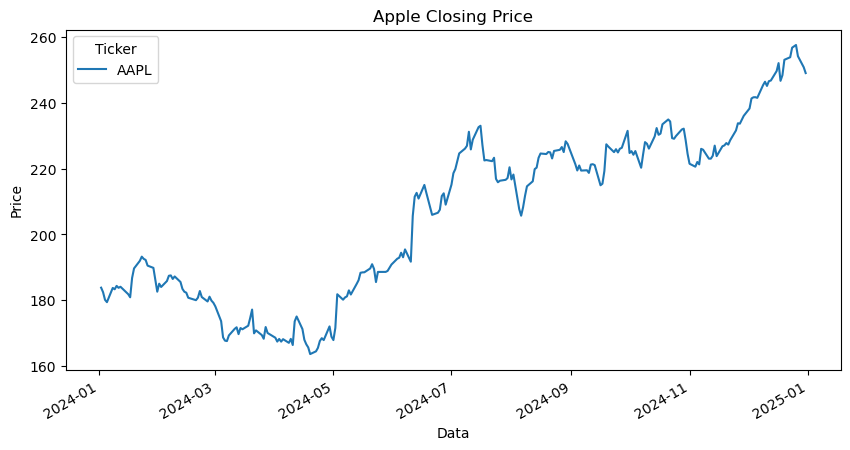

In [29]:
stock["Close"].plot(figsize=(10,5), title="Apple Closing Price")
plt.xlabel("Data")
plt.ylabel("Price")
plt.show()
stock["MA10"] =stock["Close"].rolling(10).mean()
stock["MA30"] =stock["Close"].rolling(30).mean()

## 📈 Closing Price Trend

The closing price of Apple stock shows an overall increasing trend from 2024 to early 2025. The stock gradually rises over time and reaches a peak around January 2025 and is in decreasing trend after. This indicates strong performance and a generally upward market movement during the observed period.


In [66]:
close_price=stock["Close"].squeeze()

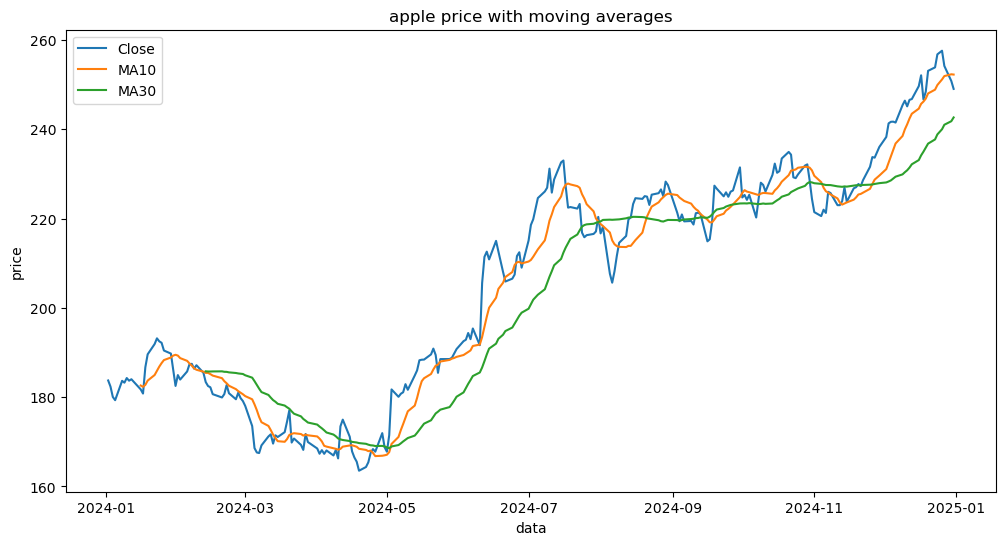

In [73]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(close_price, label="Close")
plt.plot(stock["MA10"],label="MA10")
plt.plot(stock["MA30"],label="MA30")
plt.title("apple price with moving averages")
plt.xlabel("data")
plt.ylabel("price")
plt.legend()
plt.show()
           

## 📊 Moving Averages (MA10 & MA30)

The MA10 (10-day moving average) represents the short-term trend and reacts quickly to price changes, while the MA30 (30-day moving average) represents the long-term trend and is smoother.

In the graph:
- The blue line represents the closing price
- The orange line represents MA10
- The green line represents MA30

The MA10 follows the price closely, while MA30 shows a more stable trend. The relationship between these lines helps indicate the overall direction of the stock, with the general trend showing upward movement.

In [78]:
stock["Daily Return"] = stock["Close"].pct_change()
stock[["Close","Daily Return"]].head()

Price,Close,Daily Return
Ticker,AAPL,
Date,,
2024-01-02,183.731323,NaN
2024-01-03,182.355576,-0.007488
2024-01-04,180.039658,-0.012700
2024-01-05,179.317154,-0.004013
2024-01-08,183.652130,0.024175


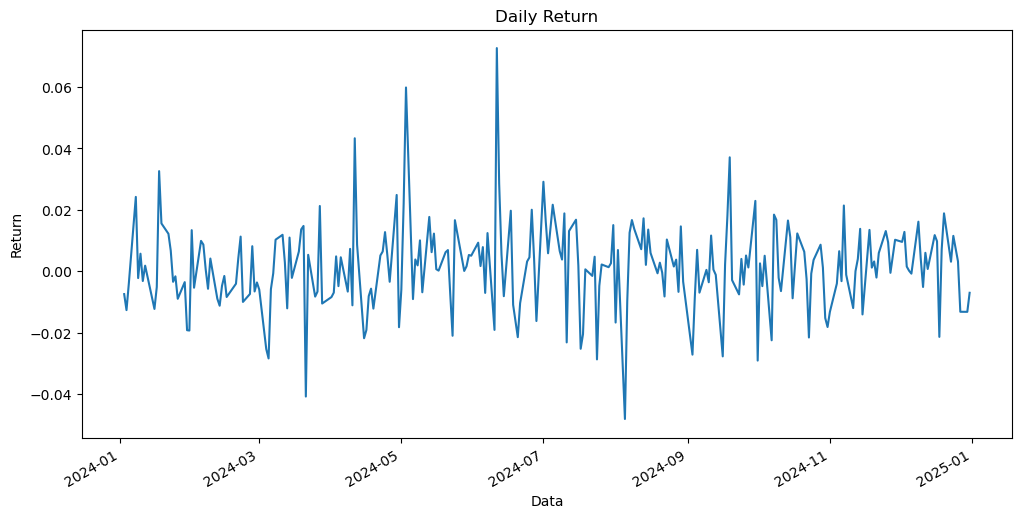

In [79]:
stock["Daily Return"].plot(figsize=(12,6), title="Daily Return")
plt.xlabel("Data")
plt.ylabel("Return")
plt.show()
                           

## 📉 Daily Return Analysis

The daily return measures the percentage change in stock price from one day to the next. The graph shows that the daily returns fluctuate between positive and negative values, indicating normal market volatility.

The returns are not constant and vary over time, reflecting short-term gains and losses in the stock price. In January 2025, the returns appear more negative, suggesting a short-term decline or correction.

In [80]:
stock[["Close","MA10","MA30","Daily Return"]].describe()

Price,Close,MA10,MA30,Daily Return
Ticker,AAPL,,,
count,252.000000,243.000000,223.000000,251.000000
mean,205.646686,205.205748,204.235782,0.001312
std,25.575701,24.745736,23.294950,0.014123
min,163.511917,166.788080,168.553682,-0.048167
25%,182.455791,182.923581,179.989808,-0.006713
50%,212.620598,213.839166,218.207715,0.001596
75%,225.913494,225.458138,223.408285,0.009332
max,257.612701,252.334572,242.663072,0.072649


In [81]:
stock["Daily Return"].std()

0.014123091615182905

## 📊 Volatility (Standard Deviation)

The standard deviation of daily returns is approximately 0.014. This value measures the volatility of the stock.

A standard deviation of 0.014 indicates moderate volatility, meaning that the stock experiences noticeable but not extreme fluctuations in its daily returns.

In [83]:
best_day=stock["Daily Return"].max()
worst_day=stock["Daily Return"].min()
print("Best daily return:", best_day)
print("Worst daily return:", worst_day)

Best daily return: 0.07264909593214641
Worst daily return: -0.04816709671025576


## 📈 Best and Worst Daily Returns

The best daily return observed is approximately 0.07, indicating a strong positive movement in the stock price on that day.

The worst daily return is approximately -0.048, showing a significant negative movement.

These values highlight the range of daily performance and demonstrate that while the stock generally trends upward, it still experiences occasional sharp increases and decreases.

###### 

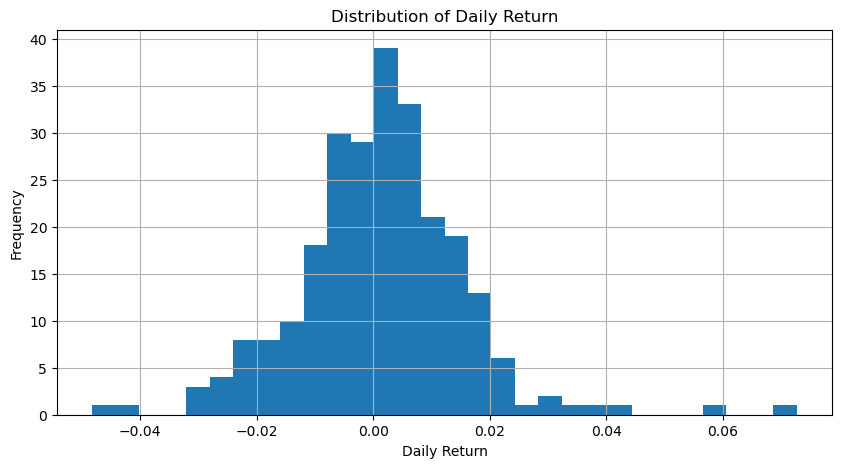

In [86]:
stock["Daily Return"].hist(bins=30,figsize=(10,5))
plt.title("Distribution of Daily Return")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

## 📊 Distribution of Daily Returns

The histogram of daily returns shows that most values are concentrated around the center, near zero. This indicates that most daily changes are relatively small.

The distribution appears approximately symmetric, suggesting a balance between positive and negative returns. However, there is a slight concentration on the positive side around 0.01, indicating a mild upward bias in returns.